In [2]:
import pandas as pd
import seaborn as sns
from sklearn.impute import KNNImputer as KNNI
from sklearn.impute import SimpleImputer as SIR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel, SelectKBest,chi2
from xgboost import XGBClassifier
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, auc, classification_report
import matplotlib.pyplot as plt
from imblearn.under_sampling import TomekLinks

In [3]:
dataset=pd.read_csv('Insurance_claims_data.csv')
features= dataset.drop(columns=['claim_status', 'policy_id']).columns.tolist()
numeric_features = dataset[features].select_dtypes(include=['number']).columns.tolist()
categorical_features = dataset[features].select_dtypes(include=['object', 'category']).columns.tolist()
X=dataset[features]
Y=dataset['claim_status']

584.4615384615385


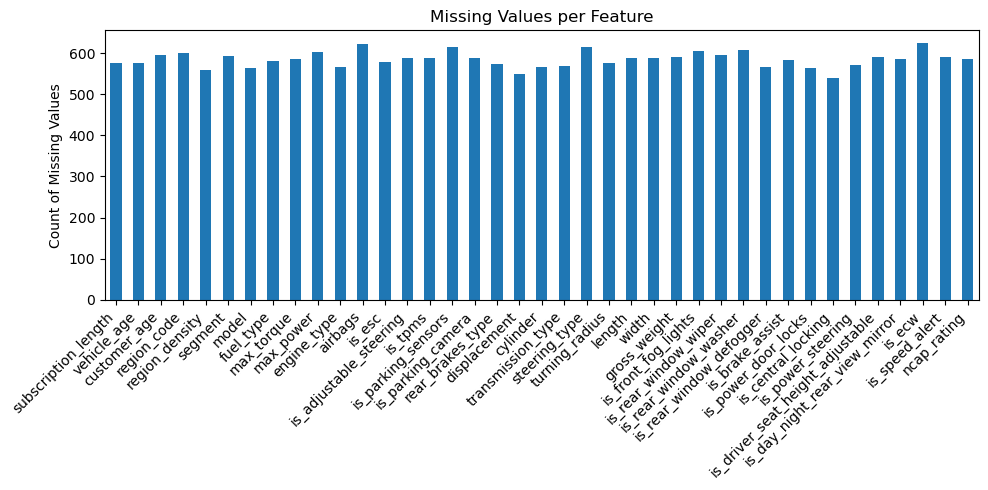

In [4]:
print(X.isnull().sum().mean())
null_counts = X.isnull().sum()
null_counts = null_counts[null_counts > 0]
null_counts.plot(kind='bar', figsize=(10, 5), title='Missing Values per Feature')
plt.ylabel('Count of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [5]:
print(Y.isnull().sum())
Y = Y.fillna(Y.mode()[0])
print(Y.isnull().sum())
print(Y.value_counts())

608
0
claim_status
0.0    55430
1.0     3747
Name: count, dtype: int64


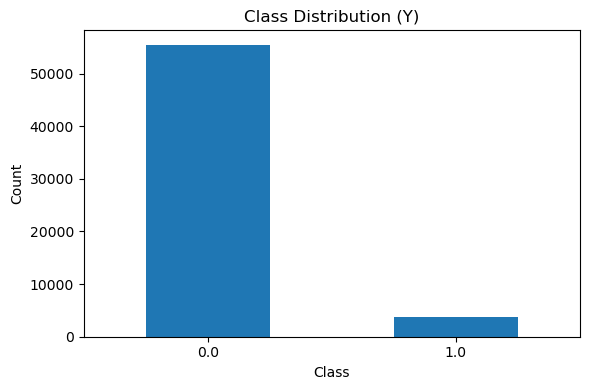

In [6]:
class_counts =Y.value_counts()
class_counts.plot(kind='bar', figsize=(6, 4), title='Class Distribution (Y)')
plt.ylabel('Count')
plt.xlabel('Class')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    Y,
    test_size=0.25,
    stratify=Y,
    random_state=42
)

In [8]:
numeric_imputer = KNNI(n_neighbors=7)
ImputedN_X_train = pd.DataFrame(numeric_imputer.fit_transform(X_train[numeric_features]),
                                columns=numeric_features, index=X_train.index)
ImputedN_X_val = pd.DataFrame(numeric_imputer.transform(X_val[numeric_features]),
                              columns=numeric_features, index=X_val.index)

scaler = MinMaxScaler()
ScaledN_X_train = pd.DataFrame(scaler.fit_transform(ImputedN_X_train),
                               columns=numeric_features, index=X_train.index)
ScaledN_X_val = pd.DataFrame(scaler.transform(ImputedN_X_val),
                             columns=numeric_features, index=X_val.index)

MyCImputer = SIR(strategy='most_frequent')
categorical_imputer = pd.DataFrame(categorical_imputer.fit_transform(X_train[categorical_features]),
                                columns=categorical_features, index=X_train.index)
categorical_imputer = pd.DataFrame(categorical_imputer.transform(X_val[categorical_features]),
                              columns=categorical_features, index=X_val.index)

In [10]:
NomC_features=[
    'region_code','segment','model','fuel_type','engine_type','rear_brakes_type','transmission_type','steering_type','max_power','max_torque']
binary_features = ['is_esc','is_adjustable_steering','is_tpms','is_parking_sensors','is_parking_camera','is_front_fog_lights',
    'is_rear_window_wiper','is_rear_window_washer','is_rear_window_defogger','is_brake_assist','is_power_door_locks',
    'is_central_locking','is_power_steering','is_driver_seat_height_adjustable','is_day_night_rear_view_mirror',
    'is_ecw','is_speed_alert']
NomEncoded_X_train = pd.get_dummies(ImputedC_X_train[NomC_features], drop_first=True)
NomEncoded_X_val = pd.get_dummies(ImputedC_X_val[NomC_features], drop_first=True)

In [11]:
for col in binary_features:
    BinImputedC_X_train = ImputedC_X_train[binary_features].replace({'Yes': 1, 'No': 0})
    BinImputedC_X_val = ImputedC_X_val[binary_features].replace({'Yes': 1, 'No': 0})

In [12]:
Final_X_train = pd.concat(
    [ScaledN_X_train, NomEncoded_X_train, BinImputedC_X_train],
    axis=1
)

Final_X_val = pd.concat(
    [ScaledN_X_val, NomEncoded_X_val, BinImputedC_X_val],
    axis=1
)
Final_X_train, Final_X_val = Final_X_train.align(Final_X_val, join='left', axis=1, fill_value=0)

In [13]:
selectK=SelectKBest(score_func=chi2,k=22)
SKX_train=selectK.fit_transform(Final_X_train,y_train)
SKX_val=selectK.transform(Final_X_val)

In [14]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=0)
rf_model.fit(Final_X_train, y_train)
selector = SelectFromModel(rf_model, threshold='median', prefit=True)
X_train_rfMedian = selector.fit_transform(Final_X_train,y_train)
X_val_rfMedian = selector.transform(Final_X_val)
MedianSFMRFselected_features = Final_X_train.columns[selector.get_support()]

In [15]:
xg_model = XGBClassifier(n_estimators=100, random_state=0)
xg_model.fit(Final_X_train, y_train)
selector = SelectFromModel(xg_model, threshold='mean', prefit=True)
X_train_xgMean = selector.fit_transform(Final_X_train,y_train)
X_val_xgMean = selector.transform(Final_X_val)
SFMselected_features = Final_X_train.columns[selector.get_support()]

In [16]:
smtk = SMOTETomek()
tk=TomekLinks()
sm=SMOTE()

X_res_rfMedian, y_res_rfMedian = smtk.fit_resample(X_train_rfMedian, y_train)

X_tkrf, y_tkrf = tk.fit_resample(X_train_rfMedian, y_train)

X_tkxg, y_tkxg = tk.fit_resample(X_train_xgMean, y_train)

X_res_xgMean, y_res_xgMean = smtk.fit_resample(X_train_xgMean, y_train)

X_SMOTErf, y_SMOTErf = sm.fit_resample(X_train_rfMedian, y_train)

X_SMOTExg, y_SMOTExg = sm.fit_resample(X_train_xgMean, y_train)

X_tkSK, y_tkSK = tk.fit_resample(SKX_train, y_train)

X_res_SK, y_res_SK = smtk.fit_resample(SKX_train, y_train)

X_SMOTESK, y_SMOTESK = sm.fit_resample(SKX_train, y_train)

In [17]:
Final_RandomForest= RandomForestClassifier(random_state=0,class_weight='balanced')
Final_XGC= XGBClassifier()
Final_MLP= MLPClassifier(max_iter=250, random_state=0)
models = [Final_RandomForest,Final_XGC,Final_MLP]
datasets = {
    "RF_Median_smtk": (X_res_rfMedian, y_res_rfMedian, X_val_rfMedian, y_val),
    "XG_Mean_smtk": (X_res_xgMean, y_res_xgMean, X_val_xgMean, y_val),
    "RF_Median_tk":(X_tkrf, y_tkrf ,X_val_rfMedian, y_val),
    "XG_Mean_tk":(X_tkxg, y_tkxg ,X_val_xgMean, y_val),
    "RF_Median_SMOTE":(X_SMOTErf, y_SMOTErf,X_val_rfMedian, y_val),
    "XG_Mean_SMOTE":(X_SMOTExg, y_SMOTExg,X_val_xgMean, y_val),
    "SK_smtk": (X_res_SK, y_res_SK , SKX_val, y_val),
    "SK_tk": (X_tkSK, y_tkSK, SKX_val, y_val),
    "SK_SMOTE": (X_SMOTESK, y_SMOTESK , SKX_val, y_val),
}
results = []
for dataset_name, (X_train, y_train, X_val, y_val) in datasets.items():
    for model in models:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        confusion = confusion_matrix(y_val, y_pred)
        class_report = classification_report(y_val, y_pred, output_dict=True)
        results.append({
            "Dataset": dataset_name,
            "Model": model.__class__.__name__,
            "Accuracy": class_report["accuracy"],
            "Precision (weighted)": class_report["weighted avg"]["precision"],
            "Recall (weighted)": class_report["weighted avg"]["recall"],
            "F1-Score (weighted)": class_report["weighted avg"]["f1-score"],
            "Precision (Fraud)": class_report["1.0"]["precision"],
            "Recall (Fraud)": class_report["1.0"]["recall"],
            "F1-Score (Fraud)": class_report["1.0"]["f1-score"],
            "TN": confusion[0, 0],
            "FP": confusion[0, 1],
            "FN": confusion[1, 0],
            "TP": confusion[1, 1],
        })

df_results = pd.DataFrame(results)

C:\Users\Hussein\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (250) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Hussein\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (250) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Hussein\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (250) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Hussein\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (250) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Hussein\anaconda3\Lib\site-packages\sklearn\metrics\_cl

In [18]:
df_results.to_csv('results.csv',index=False)